In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib import style
style.use('ggplot')
import numpy as np
import re
from nltk.stem import WordNetLemmatizer
from datasets import load_dataset, concatenate_datasets
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = load_dataset("rotten_tomatoes")
dataset_completo = concatenate_datasets([
    dataset["train"],
    dataset["validation"],
    dataset["test"]
])
tomatoes = dataset_completo.to_pandas()

In [3]:
tomatoes.head(5)

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [4]:
tomatoes.shape

(10662, 2)

In [5]:
tomatoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10662 entries, 0 to 10661
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10662 non-null  object
 1   label   10662 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 166.7+ KB


Text(0.5, 1.0, 'Distribución de las clase')

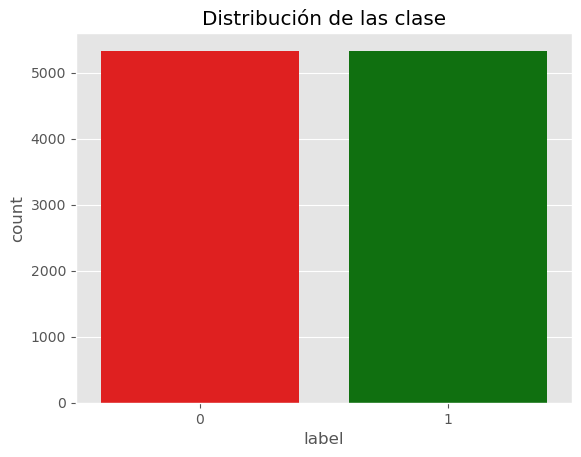

In [6]:
sns.countplot(x='label', data=tomatoes,palette={'1': 'green', '0': 'red'})
plt.title("Distribución de las clase")

In [7]:
duplicados = tomatoes.duplicated().sum()
print("Númeor de opiniones duplicadas: ", duplicados)

Númeor de opiniones duplicadas:  0


In [8]:
def conteo_palabras(x):
    palabras= x.split()
    total = len(palabras)
    return total
tomatoes['conteo_palabras'] = tomatoes['text'].apply(conteo_palabras)
tomatoes.head(5)

,text,label,conteo_palabras
0,the rock is destined to be the 21st century's ...,1,34
1,"the gorgeously elaborate continuation of "" the...",1,39
2,effective but too-tepid biopic,1,4
3,if you sometimes like to go to the movies to h...,1,21
4,"emerges as something rare , an issue movie tha...",1,21


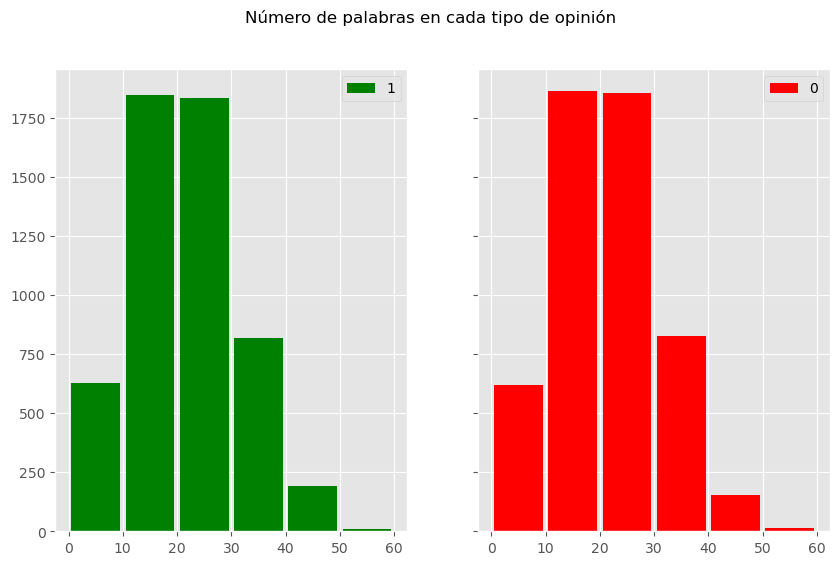

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10,6), sharex=True, sharey=True)

pos = tomatoes[tomatoes['label'] == 1]['conteo_palabras']
neg = tomatoes[tomatoes['label'] == 0]['conteo_palabras']

# mismos bins para ambos
bins = range(0, max(tomatoes['conteo_palabras']) + 10, 10)

ax[0].hist(pos, bins=bins, label='1', color='green', rwidth=0.9)
ax[0].legend(loc='upper right')

ax[1].hist(neg, bins=bins, label='0', color='red', rwidth=0.9)
ax[1].legend(loc='upper right')

fig.suptitle("Número de palabras en cada tipo de opinión")
plt.show()

In [9]:
tomatoes_ori = tomatoes.copy()

In [10]:
def limpieza(text):
    text= text.lower() #se convierte todo a minúsculas
    text = re.sub('<br />', '', text) #se quita la etiqueta HTML
    text = re.sub(r"https\S+|www\S+|http\S+", '', text, flags = re.MULTILINE) #se suprimen URL
    text = re.sub(r'\@w+|\#', '', text) #se quita caracteres especiales
    text = re.sub(r'[^\w\s]', '', text) #se suprimen signos de puntuación
    text_tokens = word_tokenize(text) #tokenización del texto
    filtro_text = [w for w in text_tokens if not w in stop_words]
    return " ".join(filtro_text)
    
tomatoes.text= tomatoes['text'].apply(limpieza)

In [11]:
lemmatizer = WordNetLemmatizer()

def lemmatization(text):
    words = word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmas)

tomatoes['text'] = tomatoes['text'].apply(lemmatization)

In [12]:
tomatoes['conteo_palabras'] = tomatoes['text'].apply(conteo_palabras)
tomatoes.head(5)

,text,label,conteo_palabras
0,rock destined 21st century new conan he going ...,1,19
1,gorgeously elaborate continuation lord ring tr...,1,21
2,effective tootepid biopic,1,3
3,sometimes like go movie fun wasabi good place ...,1,9
4,emerges something rare issue movie thats hones...,1,13


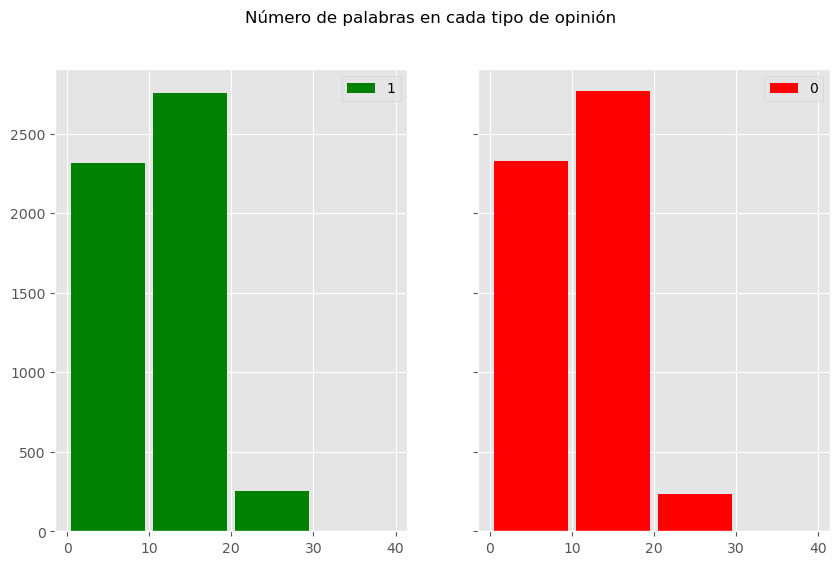

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10,6), sharex=True, sharey=True)

pos = tomatoes[tomatoes['label'] == 1]['conteo_palabras']
neg = tomatoes[tomatoes['label'] == 0]['conteo_palabras']

# mismos bins para ambos
bins = range(0, max(tomatoes['conteo_palabras']) + 10, 10)

ax[0].hist(pos, bins=bins, label='1', color='green', rwidth=0.9)
ax[0].legend(loc='upper right')

ax[1].hist(neg, bins=bins, label='0', color='red', rwidth=0.9)
ax[1].legend(loc='upper right')

fig.suptitle("Número de palabras en cada tipo de opinión")
plt.show()

In [18]:
from collections import Counter
pos = tomatoes[tomatoes['label'] == 1]
count = Counter()
for text in pos['text'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('film', 1009),
 ('movie', 650),
 ('one', 383),
 ('make', 295),
 ('story', 287),
 ('like', 284),
 ('performance', 235),
 ('character', 230),
 ('comedy', 215),
 ('time', 214),
 ('work', 206),
 ('good', 202),
 ('life', 191),
 ('way', 191),
 ('funny', 181)]

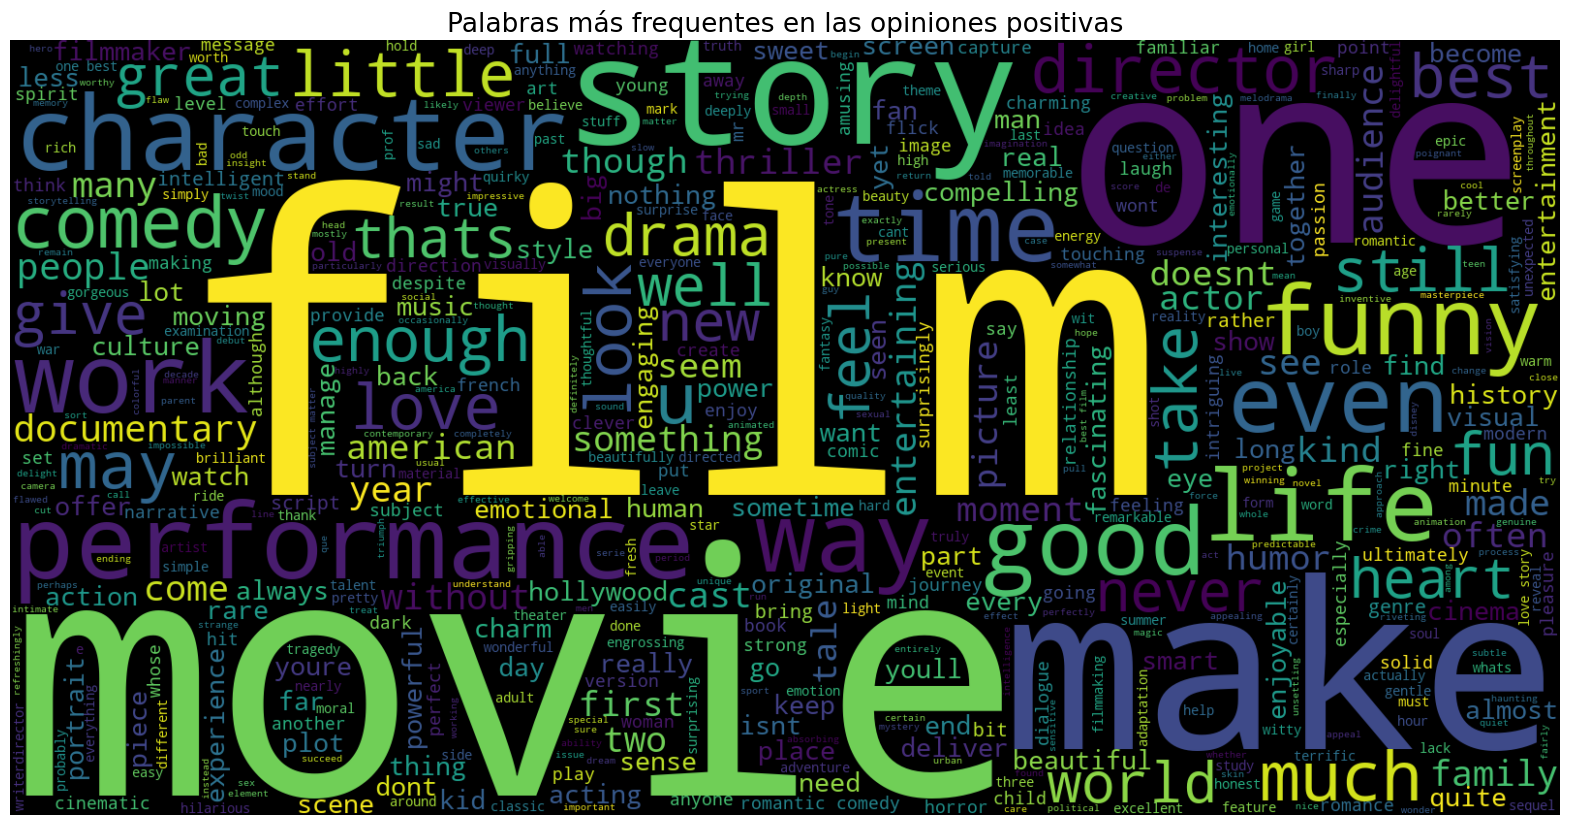

In [19]:
text = ' '.join([word for word in pos['text']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frequentes en las opiniones positivas', fontsize = 19)
plt.show()

In [20]:
from collections import Counter
pos = tomatoes[tomatoes['label'] == 0]
count = Counter()
for text in pos['text'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('movie', 895),
 ('film', 762),
 ('like', 439),
 ('one', 380),
 ('character', 253),
 ('story', 249),
 ('make', 235),
 ('much', 232),
 ('time', 229),
 ('bad', 207),
 ('even', 202),
 ('good', 179),
 ('comedy', 177),
 ('feel', 175),
 ('little', 173)]

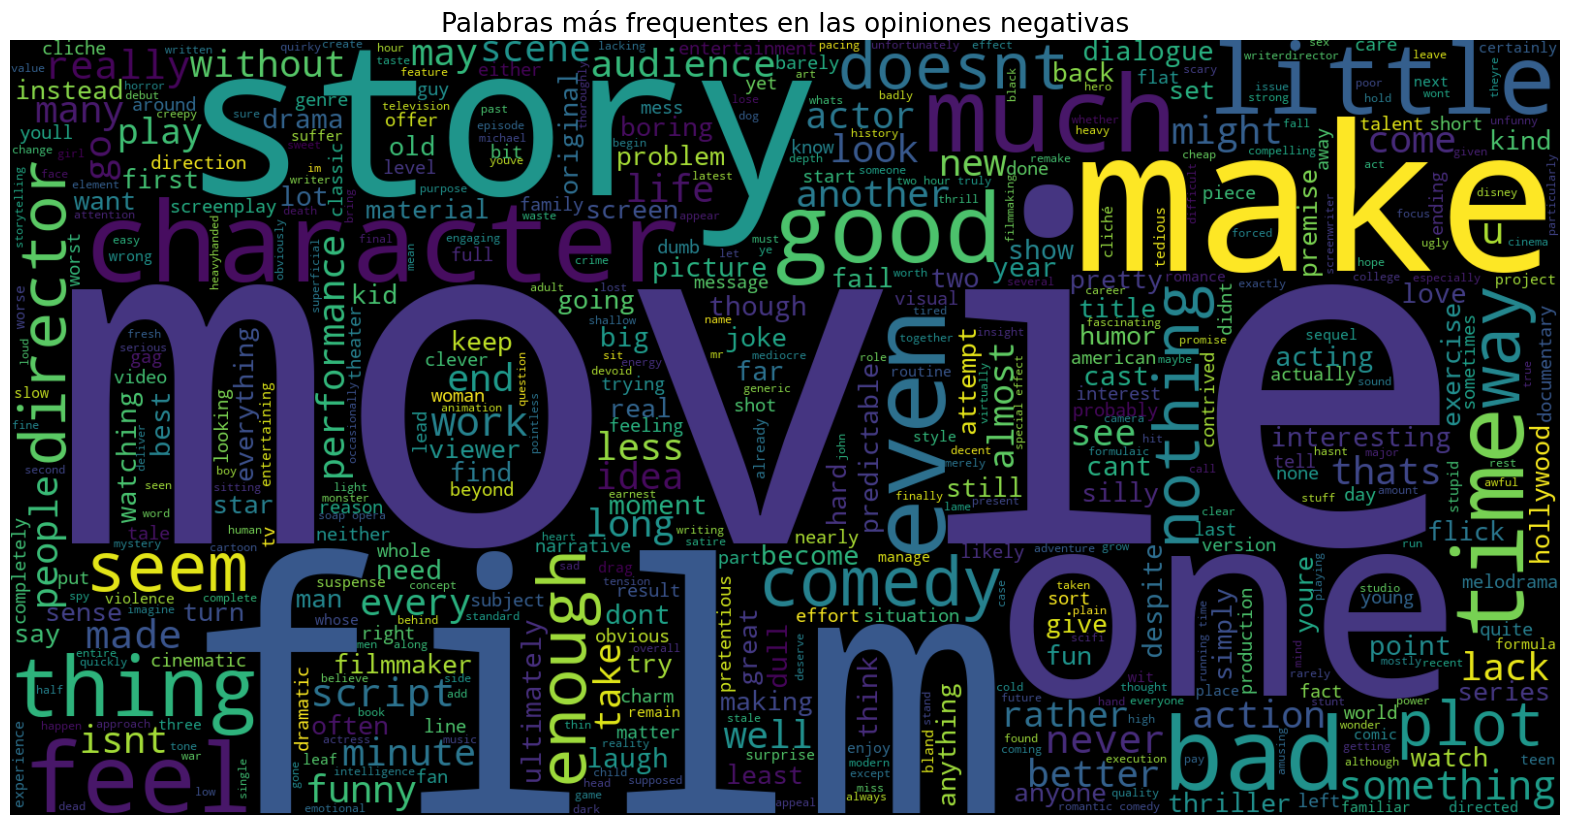

In [21]:
text = ' '.join([word for word in pos['text']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frequentes en las opiniones negativas', fontsize = 19)
plt.show()

In [13]:
x_train, x_test, y_train, y_test = train_test_split(tomatoes['text'], tomatoes['label'], test_size=0.3, random_state=42)

In [14]:
x_train_ori = tomatoes_ori.loc[x_train.index, "text"]
x_test_ori = tomatoes_ori.loc[x_test.index, "text"]

y_train_ori = tomatoes_ori.loc[x_train.index, "label"]
y_test_ori = tomatoes_ori.loc[x_test.index, "label"]

In [15]:
tf_idf = TfidfVectorizer()
x_tf_train = tf_idf.fit_transform(x_train)
x_tf_test = tf_idf.transform(x_test)

In [16]:
bag_of_words = CountVectorizer()
x_bag_train = bag_of_words.fit_transform(x_train)
x_bag_test = bag_of_words.transform(x_test)

In [17]:
bigrama_bag= CountVectorizer(ngram_range=(2,2))
x_bi_bag_train = bigrama_bag.fit_transform(x_train)
x_bi_bag_test = bigrama_bag.transform(x_test)

In [18]:
bigrama_tf = TfidfVectorizer(ngram_range=(2,2))
x_bi_tf_train = bigrama_tf.fit_transform(x_train)
x_bi_tf_test = bigrama_tf.transform(x_test)

In [30]:
rl_tf = LogisticRegression()
rl_tf.fit(x_tf_train, y_train)
rl_pred_tf = rl_tf.predict(x_tf_test)
rl_acc_tf = accuracy_score(rl_pred_tf, y_test)
print("Exactitud:", rl_acc_tf*100)

Exactitud: 75.77367927477337


In [31]:
print(confusion_matrix(y_test, rl_pred_tf))
print("\n")
print(classification_report(y_test, rl_pred_tf))

[[1236  356]
 [ 419 1188]]


              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1592
           1       0.77      0.74      0.75      1607

    accuracy                           0.76      3199
   macro avg       0.76      0.76      0.76      3199
weighted avg       0.76      0.76      0.76      3199



In [32]:
rl_bag = LogisticRegression()
rl_bag.fit(x_bag_train, y_train)
rl_pred_bag = rl_bag.predict(x_bag_test)
rl_acc_bag = accuracy_score(rl_pred_bag, y_test)
print("Exactitud:",rl_acc_bag*100)

Exactitud: 75.52360112535168


In [33]:
print(confusion_matrix(y_test, rl_pred_bag))
print("\n")
print(classification_report(y_test, rl_pred_bag))

[[1229  363]
 [ 420 1187]]


              precision    recall  f1-score   support

           0       0.75      0.77      0.76      1592
           1       0.77      0.74      0.75      1607

    accuracy                           0.76      3199
   macro avg       0.76      0.76      0.76      3199
weighted avg       0.76      0.76      0.76      3199



In [34]:
rl_bi_bag = LogisticRegression()
rl_bi_bag.fit(x_bi_bag_train, y_train)
rl_pred_bi_bag = rl_bi_bag.predict(x_bi_bag_test)
rl_acc_bi_bag = accuracy_score(rl_pred_bi_bag, y_test)
print("Exactitud:", rl_acc_tf*100)

Exactitud: 75.77367927477337


In [35]:
print(confusion_matrix(y_test, rl_pred_bi_bag))
print("\n")
print(classification_report(y_test, rl_pred_bi_bag))

[[1213  379]
 [ 917  690]]


              precision    recall  f1-score   support

           0       0.57      0.76      0.65      1592
           1       0.65      0.43      0.52      1607

    accuracy                           0.59      3199
   macro avg       0.61      0.60      0.58      3199
weighted avg       0.61      0.59      0.58      3199



In [36]:
rl_bi_tf = LogisticRegression()
rl_bi_tf.fit(x_bi_tf_train, y_train)
rl_pred_bi_tf = rl_bi_tf.predict(x_bi_tf_test)
rl_acc_bi_tf = accuracy_score(rl_pred_bi_tf, y_test)
print("Exactitud:",rl_acc_bi_tf*100)

Exactitud: 59.48733979368552


In [37]:
print(confusion_matrix(y_test, rl_pred_bi_tf))
print("\n")
print(classification_report(y_test, rl_pred_bi_tf))

[[1208  384]
 [ 912  695]]


              precision    recall  f1-score   support

           0       0.57      0.76      0.65      1592
           1       0.64      0.43      0.52      1607

    accuracy                           0.59      3199
   macro avg       0.61      0.60      0.58      3199
weighted avg       0.61      0.59      0.58      3199



In [38]:
err_tf = np.where(y_test != rl_pred_tf)[0]
err_bag = np.where(y_test != rl_pred_bag)[0]
err_bi_bag = np.where(y_test != rl_pred_bi_bag)[0]
err_bi_tf = np.where(y_test != rl_pred_bi_tf)[0]


In [39]:
err_bow = set(err_bag)
err_tfidf = set(err_tf)
err_bi_bag = set(err_bi_bag)
err_bi_tf = set(err_bi_tf)

bow_tfidf = len(err_bow & err_tfidf)
bow_bi_bag = len(err_bow & err_bi_bag)
bow_bi_tf = len(err_bow & err_bi_tf)
tfidf_bi_bag = len(err_tfidf & err_bi_bag)
tfidf_bi_tf = len(err_tfidf & err_bi_tf)
bi_bag_tf = len(err_bi_tf & err_bi_bag)

total_bow = len(err_bow)
total_tfidf = len(err_tfidf)
total_bi_bag = len(err_bi_bag)
total_bi_tf= len(err_bi_tf)

tabla = pd.DataFrame({
    "BoW": [
        total_bow,
        bow_tfidf,
        bow_bi_bag,
        bow_bi_tf
    ],
    "TF-IDF": [
        bow_tfidf,
        total_tfidf,
        tfidf_bi_bag,
        tfidf_bi_tf
    ],
    "Bigrama-Bag_of_words": [
        bow_bi_bag,
        tfidf_bi_bag,
        total_bi_bag,
        bi_bag_tf     
    ],
    "Bigrama-TF_IDF": [
        bow_bi_tf,
        tfidf_bi_tf,
        bi_bag_tf,
        total_bi_tf
        
    ]
}, index=["BoW", "TF-IDF", "Bigramas-Bag_of_words", "Bigrama-TF_IDF"])

print(tabla)

                       BoW  TF-IDF  Bigrama-Bag_of_words  Bigrama-TF_IDF
BoW                    783     660                   433             433
TF-IDF                 660     775                   447             448
Bigramas-Bag_of_words  433     447                  1296            1277
Bigrama-TF_IDF         433     448                  1277            1296


In [40]:
prob_bag = rl_bag.predict_proba(x_bag_test)[:, 1]
prob_tf = rl_tf.predict_proba(x_tf_test)[:, 1]
prob_bi_bag = rl_bi_bag.predict_proba(x_bi_bag_test)[:, 1]
prob_bi_tf = rl_bi_tf.predict_proba(x_bi_tf_test)[:, 1]

fallo_uni = (rl_pred_bag != y_test) & (rl_pred_tf != y_test)
acierto_bi = (rl_pred_bi_bag == y_test) & (rl_pred_bi_tf == y_test)
caso1 = fallo_uni & acierto_bi
indices_interesantes = np.where(caso1)[0]
ejemplo1 = indices_interesantes[:5]

for idx in ejemplo1:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", rl_pred_bag[idx])
    print("TF-IDF:", rl_pred_tf[idx])
    print("Bigram BoW:", rl_pred_bi_bag[idx])
    print("Bigram TF-IDF:", rl_pred_bi_tf[idx])
    print(f"BoW: {rl_pred_bag[idx]} (Prob: {prob_bag[idx]:.2%})")
    print(f"TF-IDF: {rl_pred_tf[idx]} (Prob: {prob_tf[idx]:.2%})")
    print(f"Bigram BoW: {rl_pred_bi_bag[idx]} (Prob: {prob_bi_bag[idx]:.2%})")
    print(f"Bigram TF-IDF: {rl_pred_bi_tf[idx]} (Prob: {prob_bi_tf[idx]:.2%})")
    print("------")


TEXTO:
too simple for its own good .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 1 (Prob: 64.78%)
TF-IDF: 1 (Prob: 74.25%)
Bigram BoW: 0 (Prob: 49.86%)
Bigram TF-IDF: 0 (Prob: 50.00%)
------
TEXTO:
exactly what it claims to be -- a simple diversion for the kids .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 1 (Prob: 57.25%)
TF-IDF: 1 (Prob: 58.60%)
Bigram BoW: 0 (Prob: 49.86%)
Bigram TF-IDF: 0 (Prob: 50.00%)
------
TEXTO:
yo , it's the days of our lives meets electric boogaloo .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 1 (Prob: 56.13%)
TF-IDF: 1 (Prob: 59.78%)
Bigram BoW: 0 (Prob: 49.86%)
Bigram TF-IDF: 0 (Prob: 50.00%)
------
TEXTO:
two weeks notice has appeal beyond being a sandra bullock vehicle or a standard romantic comedy .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 1
Bigram TF-IDF: 1
BoW: 0 (Prob: 31.04%)
TF-IDF: 0 (Prob: 44.60%)
Bigram BoW: 1 (Prob: 57.14%)
Bigram TF-IDF: 

In [41]:
fallo_bi = (rl_pred_bi_bag != y_test) & (rl_pred_bi_tf != y_test)
acierto_uni = (rl_pred_bag == y_test) & (rl_pred_tf == y_test)
caso2 = fallo_bi & acierto_uni
indices_interesantes = np.where(caso2)[0]
ejemplo2 = indices_interesantes[:5]

for idx in ejemplo2:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", rl_pred_bag[idx])
    print("TF-IDF:", rl_pred_tf[idx])
    print("Bigram BoW:", rl_pred_bi_bag[idx])
    print("Bigram TF-IDF:", rl_pred_bi_tf[idx])
    print(f"BoW: {rl_pred_bag[idx]} (Prob: {prob_bag[idx]:.2%})")
    print(f"TF-IDF: {rl_pred_tf[idx]} (Prob: {prob_tf[idx]:.2%})")
    print(f"Bigram BoW: {rl_pred_bi_bag[idx]} (Prob: {prob_bi_bag[idx]:.2%})")
    print(f"Bigram TF-IDF: {rl_pred_bi_tf[idx]} (Prob: {prob_bi_tf[idx]:.2%})")
    print("------")
    print("------")

TEXTO:
the script by david koepp is perfectly serviceable and because he gives the story some soul . . . he elevates the experience to a more mythic level .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 1 (Prob: 83.78%)
TF-IDF: 1 (Prob: 63.57%)
Bigram BoW: 0 (Prob: 44.69%)
Bigram TF-IDF: 0 (Prob: 46.14%)
------
------
TEXTO:
the message of such reflections--intentional or not--is that while no art grows from a vacuum , many artists exist in one .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 1 (Prob: 56.47%)
TF-IDF: 1 (Prob: 51.22%)
Bigram BoW: 0 (Prob: 49.86%)
Bigram TF-IDF: 0 (Prob: 50.00%)
------
------
TEXTO:
4 friends , 2 couples , 2000 miles , and all the pabst blue ribbon beer they can drink - it's the ultimate redneck road-trip .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 1 (Prob: 59.23%)
TF-IDF: 1 (Prob: 50.04%)
Bigram BoW: 0 (Prob: 49.86%)
Bigram TF-IDF: 0 (Prob: 50.00%)
------
------

In [42]:
caso3 = fallo_bi & fallo_uni
indices_interesantes = np.where(caso3)[0]
ejemplo3 = indices_interesantes[:5]

for idx in ejemplo3:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", rl_pred_bag[idx])
    print("TF-IDF:", rl_pred_tf[idx])
    print("Bigram BoW:", rl_pred_bi_bag[idx])
    print("Bigram TF-IDF:", rl_pred_bi_tf[idx])
    print(f"BoW: {rl_pred_bag[idx]} (Prob: {prob_bag[idx]:.2%})")
    print(f"TF-IDF: {rl_pred_tf[idx]} (Prob: {prob_tf[idx]:.2%})")
    print(f"Bigram BoW: {rl_pred_bi_bag[idx]} (Prob: {prob_bi_bag[idx]:.2%})")
    print(f"Bigram TF-IDF: {rl_pred_bi_tf[idx]} (Prob: {prob_bi_tf[idx]:.2%})")
    print("------")
    print("------")

TEXTO:
as a science fiction movie , " minority report " astounds .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 0 (Prob: 19.06%)
TF-IDF: 0 (Prob: 31.53%)
Bigram BoW: 0 (Prob: 29.64%)
Bigram TF-IDF: 0 (Prob: 39.87%)
------
------
TEXTO:
you can sip your vintage wines and watch your merchant ivory productions ; i'll settle for a nice cool glass of iced tea and a jerry bruckheimer flick any day of the week .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 0 (Prob: 15.92%)
TF-IDF: 0 (Prob: 36.58%)
Bigram BoW: 0 (Prob: 47.68%)
Bigram TF-IDF: 0 (Prob: 47.94%)
------
------
TEXTO:
a depressing confirmation of everything those of us who don't object to the description " unelected " have suspected all along : george w . bush is an incurious , uncharismatic , overgrown frat boy with a mean streak a mile wide .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 0 (Prob: 13.58%)
TF-IDF: 0 (Prob: 37.12%)
Bigram BoW:

In [43]:
nb_tf = MultinomialNB()
nb_tf.fit(x_tf_train, y_train)
nb_pred_tf = nb_tf.predict(x_tf_test)
nb_acc_tf = accuracy_score(nb_pred_tf, y_test)
print("Exactitud:", nb_acc_tf*100)

Exactitud: 76.18005626758362


In [44]:
print(confusion_matrix(y_test, nb_pred_tf))
print("\n")
print(classification_report(y_test, nb_pred_tf))

[[1218  374]
 [ 388 1219]]


              precision    recall  f1-score   support

           0       0.76      0.77      0.76      1592
           1       0.77      0.76      0.76      1607

    accuracy                           0.76      3199
   macro avg       0.76      0.76      0.76      3199
weighted avg       0.76      0.76      0.76      3199



In [45]:
nb_bag = MultinomialNB()
nb_bag.fit(x_bag_train, y_train)
nb_pred_bag = nb_bag.predict(x_bag_test)
nb_acc_bag = accuracy_score(nb_pred_bag, y_test)
print("Exactitud:", nb_acc_bag*100)

Exactitud: 75.71115973741794


In [46]:
print(confusion_matrix(y_test, nb_pred_bag))
print("\n")
print(classification_report(y_test, nb_pred_bag))

[[1216  376]
 [ 401 1206]]


              precision    recall  f1-score   support

           0       0.75      0.76      0.76      1592
           1       0.76      0.75      0.76      1607

    accuracy                           0.76      3199
   macro avg       0.76      0.76      0.76      3199
weighted avg       0.76      0.76      0.76      3199



In [47]:
nb_bi_bag = MultinomialNB()
nb_bi_bag.fit(x_bi_bag_train, y_train)
nb_pred_bi_bag = nb_bi_bag.predict(x_bi_bag_test)
nb_acc_bi_bag = accuracy_score(nb_pred_bi_bag, y_test)
print("Exactitud:", nb_acc_bi_bag*100)

Exactitud: 59.79993748046264


In [48]:
print(confusion_matrix(y_test, nb_pred_bi_bag))
print("\n")
print(classification_report(y_test, nb_pred_bi_bag))

[[1259  333]
 [ 953  654]]


              precision    recall  f1-score   support

           0       0.57      0.79      0.66      1592
           1       0.66      0.41      0.50      1607

    accuracy                           0.60      3199
   macro avg       0.62      0.60      0.58      3199
weighted avg       0.62      0.60      0.58      3199



In [49]:
nb_bi_tf = MultinomialNB()
nb_bi_tf.fit(x_bi_tf_train, y_train)
nb_pred_bi_tf = nb_bi_tf.predict(x_bi_tf_test)
nb_acc_bi_tf = accuracy_score(nb_pred_bi_tf, y_test)
print("Exactitud:", nb_acc_bi_tf*100)

Exactitud: 59.48733979368552


In [50]:
print(confusion_matrix(y_test, nb_pred_bi_tf))
print("\n")
print(classification_report(y_test, nb_pred_bi_tf))

[[1213  379]
 [ 917  690]]


              precision    recall  f1-score   support

           0       0.57      0.76      0.65      1592
           1       0.65      0.43      0.52      1607

    accuracy                           0.59      3199
   macro avg       0.61      0.60      0.58      3199
weighted avg       0.61      0.59      0.58      3199



In [51]:
nb_err_bag = np.where(y_test != nb_pred_bag)[0]
nb_err_bi_bag = np.where(y_test != nb_pred_bi_bag)[0]
nb_err_bi_tf = np.where(y_test != nb_pred_bi_tf)[0]
nb_err_tf = np.where(y_test != nb_pred_tf)[0]

In [52]:
nb_err_bow = set(nb_err_bag)
nb_err_tfidf = set(nb_err_tf)
nb_err_bi_bag = set(nb_err_bi_bag)
nb_err_bi_tf = set(nb_err_bi_tf)

nb_bow_tfidf = len(nb_err_bow & nb_err_tfidf)
nb_bow_bi_bag = len(nb_err_bow & nb_err_bi_bag)
nb_bow_bi_tf = len(nb_err_bow & nb_err_bi_tf)
nb_tfidf_bi_bag = len(nb_err_tfidf & nb_err_bi_bag)
nb_tfidf_bi_tf = len(nb_err_tfidf & nb_err_bi_tf)
nb_bi_bag_tf = len(nb_err_bi_tf & nb_err_bi_bag)

nb_total_bow = len(err_bow)
nb_total_tfidf = len(err_tfidf)
nb_total_bi_bag = len(err_bi_bag)
nb_total_bi_tf= len(err_bi_tf)

tabla = pd.DataFrame({
    "BoW": [
        nb_total_bow,
        nb_bow_tfidf,
        nb_bow_bi_bag,
        nb_bow_bi_tf
    ],
    "TF-IDF": [
        nb_bow_tfidf,
        nb_total_tfidf,
        nb_tfidf_bi_bag,
        nb_tfidf_bi_tf
    ],
    "Bigrama-Bag_of_words": [
        nb_bow_bi_bag,
        nb_tfidf_bi_bag,
        nb_total_bi_bag,
        nb_bi_bag_tf     
    ],
    "Bigrama-TF_IDF": [
        nb_bow_bi_tf,
        nb_tfidf_bi_tf,
        nb_bi_bag_tf,
        nb_total_bi_tf
        
    ]
}, index=["BoW", "TF-IDF", "Bigramas-Bag_of_words", "Bigrama-TF_IDF"])

print(tabla)

                       BoW  TF-IDF  Bigrama-Bag_of_words  Bigrama-TF_IDF
BoW                    783     714                   416             417
TF-IDF                 714     775                   410             411
Bigramas-Bag_of_words  416     410                  1296            1230
Bigrama-TF_IDF         417     411                  1230            1296


In [53]:
fallo_uni = (nb_pred_bag != y_test) & (nb_pred_tf != y_test)
acierto_bi = (nb_pred_bi_bag == y_test) & (nb_pred_bi_tf == y_test)
caso1 = fallo_uni & acierto_bi
indices_interesantes = np.where(caso1)[0]
ejemplo1 = indices_interesantes[:5]

for idx in ejemplo1:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", nb_pred_bag[idx])
    print("TF-IDF:", nb_pred_tf[idx])
    print("Bigram BoW:", nb_pred_bi_bag[idx])
    print("Bigram TF-IDF:", nb_pred_bi_tf[idx])
    print("------")


TEXTO:
too simple for its own good .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
exactly what it claims to be -- a simple diversion for the kids .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
yo , it's the days of our lives meets electric boogaloo .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
while american adobo has its heart ( and its palate ) in the right place , its brain is a little scattered -- ditsy , even .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
the movie doesn't add anything fresh to the myth .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------


In [54]:
fallo_bi = (nb_pred_bi_bag != y_test) & (nb_pred_bi_tf != y_test)
acierto_uni = (nb_pred_bag == y_test) & (nb_pred_tf == y_test)
caso2 = fallo_bi & acierto_uni
indices_interesantes = np.where(caso2)[0]
ejemplo2 = indices_interesantes[:5]

for idx in ejemplo2:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", nb_pred_bag[idx])
    print("TF-IDF:", nb_pred_tf[idx])
    print("Bigram BoW:", nb_pred_bi_bag[idx])
    print("Bigram TF-IDF:", nb_pred_bi_tf[idx])
    print("------")

TEXTO:
the script by david koepp is perfectly serviceable and because he gives the story some soul . . . he elevates the experience to a more mythic level .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
this is a harrowing movie about how parents know where all the buttons are , and how to push them .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
makes an aborbing if arguable case for the man's greatness .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
offers enough playful fun to entertain the preschool set while embracing a wholesome attitude .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
the story ultimately takes hold and grips hard .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------


In [55]:
caso3 = fallo_bi & fallo_uni
indices_interesantes = np.where(caso3)[0]
ejemplo3 = indices_interesantes[:5]

for idx in ejemplo3:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", nb_pred_bag[idx])
    print("TF-IDF:", nb_pred_tf[idx])
    print("Bigram BoW:", nb_pred_bi_bag[idx])
    print("Bigram TF-IDF:", nb_pred_bi_tf[idx])
    print("------")

TEXTO:
as a science fiction movie , " minority report " astounds .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
you can sip your vintage wines and watch your merchant ivory productions ; i'll settle for a nice cool glass of iced tea and a jerry bruckheimer flick any day of the week .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
the message of such reflections--intentional or not--is that while no art grows from a vacuum , many artists exist in one .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
the overall effect is awe and affection -- and a strange urge to get on a board and , uh , shred , dude .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
a depressing confirmation of everything those of us who don't object to the description " unelected " have suspected all along : george w . bush is an incurious , uncharismatic , overgrown f

In [19]:
svm_tf = LinearSVC()
svm_tf.fit(x_tf_train, y_train)
svm_pred_tf = svm_tf.predict(x_tf_test)
svm_acc_tf = accuracy_score(svm_pred_tf, y_test)
print("Exactitud:", svm_acc_tf*100)

Exactitud: 74.89840575179744


In [20]:
print(confusion_matrix(y_test, svm_pred_tf))
print("\n")
print(classification_report(y_test, svm_pred_tf))

[[1212  380]
 [ 423 1184]]


              precision    recall  f1-score   support

           0       0.74      0.76      0.75      1592
           1       0.76      0.74      0.75      1607

    accuracy                           0.75      3199
   macro avg       0.75      0.75      0.75      3199
weighted avg       0.75      0.75      0.75      3199



In [21]:
svm_bag = LinearSVC()
svm_bag.fit(x_bag_train, y_train)
svm_pred_bag = svm_bag.predict(x_bag_test)
svm_acc_bag = accuracy_score(svm_pred_bag, y_test)
print("Exactitud:", svm_acc_bag*100)

Exactitud: 72.77274148171303


In [22]:
print(confusion_matrix(y_test, svm_pred_bag))
print("\n")
print(classification_report(y_test, svm_pred_bag))

[[1170  422]
 [ 449 1158]]


              precision    recall  f1-score   support

           0       0.72      0.73      0.73      1592
           1       0.73      0.72      0.73      1607

    accuracy                           0.73      3199
   macro avg       0.73      0.73      0.73      3199
weighted avg       0.73      0.73      0.73      3199



In [23]:
svm_bi_bag = LinearSVC()
svm_bi_bag.fit(x_bi_bag_train, y_train)
svm_pred_bi_bag = svm_bi_bag.predict(x_bi_bag_test)
svm_acc_bi_bag = accuracy_score(svm_pred_bi_bag, y_test)
print("Exactitud:", svm_acc_bi_bag*100)

Exactitud: 59.237261644263825


In [24]:
print(confusion_matrix(y_test, svm_pred_bi_bag))
print("\n")
print(classification_report(y_test, svm_pred_bi_bag))

[[1228  364]
 [ 940  667]]


              precision    recall  f1-score   support

           0       0.57      0.77      0.65      1592
           1       0.65      0.42      0.51      1607

    accuracy                           0.59      3199
   macro avg       0.61      0.59      0.58      3199
weighted avg       0.61      0.59      0.58      3199



In [25]:
svm_bi_tf = LinearSVC()
svm_bi_tf.fit(x_bi_tf_train, y_train)
svm_pred_bi_tf = svm_bi_tf.predict(x_bi_tf_test)
svm_acc_bi_tf = accuracy_score(svm_pred_bi_tf, y_test)
print("Exactitud:", svm_acc_bi_tf*100)

Exactitud: 60.51891216005002


In [26]:
print(confusion_matrix(y_test, svm_pred_bi_tf))
print("\n")
print(classification_report(y_test, svm_pred_bi_tf))

[[ 757  835]
 [ 428 1179]]


              precision    recall  f1-score   support

           0       0.64      0.48      0.55      1592
           1       0.59      0.73      0.65      1607

    accuracy                           0.61      3199
   macro avg       0.61      0.60      0.60      3199
weighted avg       0.61      0.61      0.60      3199



In [27]:
svm_err_bag = np.where(y_test != svm_pred_bag)[0]
svm_err_bi_bag = np.where(y_test != svm_pred_bi_bag)[0]
svm_err_bi_tf = np.where(y_test != svm_pred_bi_tf)[0]
svm_err_tf = np.where(y_test != svm_pred_tf)[0]

In [28]:
svm_err_bow = set(svm_err_bag)
svm_err_tfidf = set(svm_err_tf)
svm_err_bi_bag = set(svm_err_bi_bag)
svm_err_bi_tf = set(svm_err_bi_tf)

svm_bow_tfidf = len(svm_err_bow & svm_err_tfidf)
svm_bow_bi_bag = len(svm_err_bow & svm_err_bi_bag)
svm_bow_bi_tf = len(svm_err_bow & svm_err_bi_tf)
svm_tfidf_bi_bag = len(svm_err_tfidf & svm_err_bi_bag)
svm_tfidf_bi_tf = len(svm_err_tfidf & svm_err_bi_tf)
svm_bi_bag_tf = len(svm_err_bi_tf & svm_err_bi_bag)

svm_total_bow = len(svm_err_bow)
svm_total_tfidf = len(svm_err_tfidf)
svm_total_bi_bag = len(svm_err_bi_bag)
svm_total_bi_tf= len(svm_err_bi_tf)

tabla = pd.DataFrame({
    "BoW": [
        svm_total_bow,
        svm_bow_tfidf,
        svm_bow_bi_bag,
        svm_bow_bi_tf
    ],
    "TF-IDF": [
        svm_bow_tfidf,
        svm_total_tfidf,
        svm_tfidf_bi_bag,
        svm_tfidf_bi_tf
    ],
    "Bigrama-Bag_of_words": [
        svm_bow_bi_bag,
        svm_tfidf_bi_bag,
        svm_total_bi_bag,
        svm_bi_bag_tf     
    ],
    "Bigrama-TF_IDF": [
        svm_bow_bi_tf,
        svm_tfidf_bi_tf,
        svm_bi_bag_tf,
        svm_total_bi_tf
        
    ]
}, index=["BoW", "TF-IDF", "Bigramas-Bag_of_words", "Bigrama-TF_IDF"])

print(tabla)

                       BoW  TF-IDF  Bigrama-Bag_of_words  Bigrama-TF_IDF
BoW                    871     720                   456             470
TF-IDF                 720     803                   425             440
Bigramas-Bag_of_words  456     425                  1304             770
Bigrama-TF_IDF         470     440                   770            1263


In [29]:
fallo_uni = (svm_pred_bag != y_test) & (svm_pred_tf != y_test)
acierto_bi = (svm_pred_bi_bag == y_test) & (svm_pred_bi_tf == y_test)
caso1 = fallo_uni & acierto_bi
indices_interesantes = np.where(caso1)[0]
ejemplo1 = indices_interesantes[:5]

for idx in ejemplo1:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", svm_pred_bag[idx])
    print("TF-IDF:", svm_pred_tf[idx])
    print("Bigram BoW:", svm_pred_bi_bag[idx])
    print("Bigram TF-IDF:", svm_pred_bi_tf[idx])
    print("------")


TEXTO:
although it lacks the detail of the book , the film does pack some serious suspense .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 1
Bigram TF-IDF: 1
------
TEXTO:
" bad " is the operative word for " bad company , " and i don't mean that in a good way .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
two weeks notice has appeal beyond being a sandra bullock vehicle or a standard romantic comedy .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 1
Bigram TF-IDF: 1
------
TEXTO:
the film offers an intriguing what-if premise .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 1
Bigram TF-IDF: 1
------
TEXTO:
this is surely one of the most frantic , virulent and foul-natured christmas season pics ever delivered by a hollywood studio .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------


In [30]:
fallo_bi = (svm_pred_bi_bag != y_test) & (svm_pred_bi_tf != y_test)
acierto_uni = (svm_pred_bag == y_test) & (svm_pred_tf == y_test)
caso2 = fallo_bi & acierto_uni
indices_interesantes = np.where(caso2)[0]
ejemplo2 = indices_interesantes[:5]

for idx in ejemplo2:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", svm_pred_bag[idx])
    print("TF-IDF:", svm_pred_tf[idx])
    print("Bigram BoW:", svm_pred_bi_bag[idx])
    print("Bigram TF-IDF:", svm_pred_bi_tf[idx])
    print("------")

TEXTO:
the script by david koepp is perfectly serviceable and because he gives the story some soul . . . he elevates the experience to a more mythic level .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
the overall effect is awe and affection -- and a strange urge to get on a board and , uh , shred , dude .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
while the path may be familiar , first-time director denzel washington and a top-notch cast manage to keep things interesting .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
franco is an excellent choice for the walled-off but combustible hustler , but he does not give the transcendent performance sonny needs to overcome gaps in character development and story logic .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
as a movie , it never seems fresh and vital . it never plays as dramatic

In [31]:
caso3 = fallo_bi & fallo_uni
indices_interesantes = np.where(caso3)[0]
ejemplo3 = indices_interesantes[:5]

for idx in ejemplo3:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", svm_pred_bag[idx])
    print("TF-IDF:", svm_pred_tf[idx])
    print("Bigram BoW:", svm_pred_bi_bag[idx])
    print("Bigram TF-IDF:", svm_pred_bi_tf[idx])
    print("------")

TEXTO:
as a science fiction movie , " minority report " astounds .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
you can sip your vintage wines and watch your merchant ivory productions ; i'll settle for a nice cool glass of iced tea and a jerry bruckheimer flick any day of the week .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
a depressing confirmation of everything those of us who don't object to the description " unelected " have suspected all along : george w . bush is an incurious , uncharismatic , overgrown frat boy with a mean streak a mile wide .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
only two words will tell you what you know when deciding to see it : anthony . hopkins .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
if there's a way to effectively teach kids about the dangers of drugs , i think it's in projects lik

In [69]:
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, solver='adam', early_stopping=True, verbose=True)
mlp.fit(x_tf_train, y_train)
mlp_pred_tf = mlp.predict(x_tf_test)
mlp_acc_tf = accuracy_score(mlp_pred_tf, y_test)
print("Exactitud:", mlp_acc_tf*100)

Iteration 1, loss = 0.69021343
Validation score: 0.625167
Iteration 2, loss = 0.64341234
Validation score: 0.763052
Iteration 3, loss = 0.56867434
Validation score: 0.765730
Iteration 4, loss = 0.47690147
Validation score: 0.772423
Iteration 5, loss = 0.38951806
Validation score: 0.776439
Iteration 6, loss = 0.31652723
Validation score: 0.772423
Iteration 7, loss = 0.25965096
Validation score: 0.777778
Iteration 8, loss = 0.21550291
Validation score: 0.775100
Iteration 9, loss = 0.18141028
Validation score: 0.773762
Iteration 10, loss = 0.15405274
Validation score: 0.764391
Iteration 11, loss = 0.13176361
Validation score: 0.761714
Iteration 12, loss = 0.11392019
Validation score: 0.765730
Iteration 13, loss = 0.09914899
Validation score: 0.759036
Iteration 14, loss = 0.08690933
Validation score: 0.759036
Iteration 15, loss = 0.07673506
Validation score: 0.751004
Iteration 16, loss = 0.06792476
Validation score: 0.753681
Iteration 17, loss = 0.06072102
Validation score: 0.751004
Iterat

In [70]:
print(confusion_matrix(y_test, mlp_pred_tf))
print("\n")
print(classification_report(y_test, mlp_pred_tf))

[[1218  374]
 [ 415 1192]]


              precision    recall  f1-score   support

           0       0.75      0.77      0.76      1592
           1       0.76      0.74      0.75      1607

    accuracy                           0.75      3199
   macro avg       0.75      0.75      0.75      3199
weighted avg       0.75      0.75      0.75      3199



In [71]:
mlp_bag = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, solver='adam', early_stopping=True, verbose=True)
mlp_bag.fit(x_bag_train, y_train)
mlp_pred_bag = mlp_bag.predict(x_bag_test)
mlp_acc_bag = accuracy_score(mlp_pred_bag, y_test)
print("Exactitud:", mlp_acc_bag*100)

Iteration 1, loss = 0.67238766
Validation score: 0.745649
Iteration 2, loss = 0.54152249
Validation score: 0.757697
Iteration 3, loss = 0.40189585
Validation score: 0.760375
Iteration 4, loss = 0.29688250
Validation score: 0.767068
Iteration 5, loss = 0.22496422
Validation score: 0.753681
Iteration 6, loss = 0.17452687
Validation score: 0.756359
Iteration 7, loss = 0.13933585
Validation score: 0.757697
Iteration 8, loss = 0.11268192
Validation score: 0.756359
Iteration 9, loss = 0.09312748
Validation score: 0.757697
Iteration 10, loss = 0.07793705
Validation score: 0.757697
Iteration 11, loss = 0.06613701
Validation score: 0.757697
Iteration 12, loss = 0.05670455
Validation score: 0.759036
Iteration 13, loss = 0.04929956
Validation score: 0.768407
Iteration 14, loss = 0.04320107
Validation score: 0.763052
Iteration 15, loss = 0.03802664
Validation score: 0.768407
Iteration 16, loss = 0.03376441
Validation score: 0.763052
Iteration 17, loss = 0.03024485
Validation score: 0.764391
Iterat

In [72]:
print(confusion_matrix(y_test, mlp_pred_bag))
print("\n")
print(classification_report(y_test, mlp_pred_bag))

[[1194  398]
 [ 413 1194]]


              precision    recall  f1-score   support

           0       0.74      0.75      0.75      1592
           1       0.75      0.74      0.75      1607

    accuracy                           0.75      3199
   macro avg       0.75      0.75      0.75      3199
weighted avg       0.75      0.75      0.75      3199



In [73]:
mlp_bi_bag = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, solver='adam', early_stopping=True, verbose=True)
mlp_bi_bag.fit(x_bi_bag_train, y_train)
mlp_pred_bi_bag = mlp_bi_bag.predict(x_bi_bag_test)
mlp_acc_bi_bag = accuracy_score(mlp_pred_bi_bag, y_test)
print("Exactitud:", mlp_acc_bi_bag*100)

Iteration 1, loss = 0.69370324
Validation score: 0.542169
Iteration 2, loss = 0.58257986
Validation score: 0.627845
Iteration 3, loss = 0.39625718
Validation score: 0.633199
Iteration 4, loss = 0.21214691
Validation score: 0.631861
Iteration 5, loss = 0.12308783
Validation score: 0.635877
Iteration 6, loss = 0.08007439
Validation score: 0.634538
Iteration 7, loss = 0.05683297
Validation score: 0.634538
Iteration 8, loss = 0.04281520
Validation score: 0.634538
Iteration 9, loss = 0.03358550
Validation score: 0.635877
Iteration 10, loss = 0.02723077
Validation score: 0.637216
Iteration 11, loss = 0.02263895
Validation score: 0.635877
Iteration 12, loss = 0.01915166
Validation score: 0.637216
Iteration 13, loss = 0.01649577
Validation score: 0.638554
Iteration 14, loss = 0.01440071
Validation score: 0.638554
Iteration 15, loss = 0.01273026
Validation score: 0.637216
Iteration 16, loss = 0.01137369
Validation score: 0.635877
Iteration 17, loss = 0.01024178
Validation score: 0.637216
Iterat

In [74]:
print(confusion_matrix(y_test, mlp_pred_bi_bag))
print("\n")
print(classification_report(y_test, mlp_pred_bi_bag))

[[1224  368]
 [ 935  672]]


              precision    recall  f1-score   support

           0       0.57      0.77      0.65      1592
           1       0.65      0.42      0.51      1607

    accuracy                           0.59      3199
   macro avg       0.61      0.59      0.58      3199
weighted avg       0.61      0.59      0.58      3199



In [75]:
mlp_bi_tf = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, solver='adam', early_stopping=True, verbose=True)
mlp_bi_tf.fit(x_bi_tf_train, y_train)
mlp_pred_bi_tf = mlp_bi_tf.predict(x_bi_tf_test)
mlp_acc_bi_tf = accuracy_score(mlp_pred_bi_tf, y_test)
print("Exactitud:", mlp_acc_bi_tf*100)

Iteration 1, loss = 0.69775316
Validation score: 0.499331
Iteration 2, loss = 0.66339683
Validation score: 0.512718
Iteration 3, loss = 0.59322718
Validation score: 0.609103
Iteration 4, loss = 0.46457893
Validation score: 0.629183
Iteration 5, loss = 0.33018085
Validation score: 0.627845
Iteration 6, loss = 0.22547777
Validation score: 0.630522
Iteration 7, loss = 0.15425671
Validation score: 0.629183
Iteration 8, loss = 0.10922057
Validation score: 0.606426
Iteration 9, loss = 0.08047794
Validation score: 0.603748
Iteration 10, loss = 0.06162115
Validation score: 0.609103
Iteration 11, loss = 0.04875451
Validation score: 0.603748
Iteration 12, loss = 0.03962718
Validation score: 0.607764
Iteration 13, loss = 0.03300123
Validation score: 0.607764
Iteration 14, loss = 0.02801477
Validation score: 0.609103
Iteration 15, loss = 0.02416726
Validation score: 0.605087
Iteration 16, loss = 0.02119082
Validation score: 0.609103
Iteration 17, loss = 0.01878472
Validation score: 0.607764
Valida

In [76]:
print(confusion_matrix(y_test, mlp_pred_bi_tf))
print("\n")
print(classification_report(y_test, mlp_pred_bi_tf))

[[ 701  891]
 [ 390 1217]]


              precision    recall  f1-score   support

           0       0.64      0.44      0.52      1592
           1       0.58      0.76      0.66      1607

    accuracy                           0.60      3199
   macro avg       0.61      0.60      0.59      3199
weighted avg       0.61      0.60      0.59      3199



In [81]:
mlp_err_bag = np.where(y_test != mlp_pred_bag)[0]
mlp_err_bi_bag = np.where(y_test != mlp_pred_bi_bag)[0]
mlp_err_bi_tf = np.where(y_test != mlp_pred_bi_tf)[0]
mlp_err_tf = np.where(y_test != mlp_pred_tf)[0]

In [82]:
mlp_err_bow = set(mlp_err_bag)
mlp_err_tfidf = set(mlp_err_tf)
mlp_err_bi_bag = set(mlp_err_bi_bag)
mlp_err_bi_tf = set(mlp_err_bi_tf)

mlp_bow_tfidf = len(mlp_err_bow & mlp_err_tfidf)
mlp_bow_bi_bag = len(mlp_err_bow & mlp_err_bi_bag)
mlp_bow_bi_tf = len(mlp_err_bow & mlp_err_bi_tf)
mlp_tfidf_bi_bag = len(mlp_err_tfidf & mlp_err_bi_bag)
mlp_tfidf_bi_tf = len(mlp_err_tfidf & mlp_err_bi_tf)
mlp_bi_bag_tf = len(mlp_err_bi_tf & mlp_err_bi_bag)

mlp_total_bow = len(mlp_err_bow)
mlp_total_tfidf = len(mlp_err_tfidf)
mlp_total_bi_bag = len(mlp_err_bi_bag)
mlp_total_bi_tf= len(mlp_err_bi_tf)

tabla = pd.DataFrame({
    "BoW": [
        mlp_total_bow,
        mlp_bow_tfidf,
        mlp_bow_bi_bag,
        mlp_bow_bi_tf
    ],
    "TF-IDF": [
        mlp_bow_tfidf,
        mlp_total_tfidf,
        mlp_tfidf_bi_bag,
        mlp_tfidf_bi_tf
    ],
    "Bigrama-Bag_of_words": [
        mlp_bow_bi_bag,
        mlp_tfidf_bi_bag,
        mlp_total_bi_bag,
        mlp_bi_bag_tf     
    ],
    "Bigrama-TF_IDF": [
        mlp_bow_bi_tf,
        mlp_tfidf_bi_tf,
        mlp_bi_bag_tf,
        mlp_total_bi_tf
        
    ]
}, index=["BoW", "TF-IDF", "Bigramas-Bag_of_words", "Bigrama-TF_IDF"])

print(tabla)

                       BoW  TF-IDF  Bigrama-Bag_of_words  Bigrama-TF_IDF
BoW                    811     618                   421             436
TF-IDF                 618     789                   420             431
Bigramas-Bag_of_words  421     420                  1303             679
Bigrama-TF_IDF         436     431                   679            1281


In [83]:
fallo_uni = (mlp_pred_bag != y_test) & (mlp_pred_tf != y_test)
acierto_bi = (mlp_pred_bi_bag == y_test) & (mlp_pred_bi_tf == y_test)
caso1 = fallo_uni & acierto_bi
indices_interesantes = np.where(caso1)[0]
ejemplo1 = indices_interesantes[:5]

for idx in ejemplo1:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", mlp_pred_bag[idx])
    print("TF-IDF:", mlp_pred_tf[idx])
    print("Bigram BoW:", mlp_pred_bi_bag[idx])
    print("Bigram TF-IDF:", mlp_pred_bi_tf[idx])
    print("------")


TEXTO:
as they used to say in the 1950s sci-fi movies , signs is a tribute to shyamalan's gifts , which are such that we'll keep watching the skies for his next project .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 1
Bigram TF-IDF: 1
------
TEXTO:
. . . just a big mess of a movie , full of images and events , but no tension or surprise .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
though ganesh is successful in a midlevel sort of way , there's nothing so striking or fascinating or metaphorically significant about his career as to rate two hours of our attention .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
if you enjoy being rewarded by a script that assumes you aren't very bright , then blood work is for you .

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
it lets you brush up against the humanity of a psycho , without making him any less psycho .

Prediccion

In [84]:
fallo_bi = (mlp_pred_bi_bag != y_test) & (mlp_pred_bi_tf != y_test)
acierto_uni = (mlp_pred_bag == y_test) & (mlp_pred_tf == y_test)
caso2 = fallo_bi & acierto_uni
indices_interesantes = np.where(caso2)[0]
ejemplo2 = indices_interesantes[:5]

for idx in ejemplo2:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", mlp_pred_bag[idx])
    print("TF-IDF:", mlp_pred_tf[idx])
    print("Bigram BoW:", mlp_pred_bi_bag[idx])
    print("Bigram TF-IDF:", mlp_pred_bi_tf[idx])
    print("------")

TEXTO:
the script by david koepp is perfectly serviceable and because he gives the story some soul . . . he elevates the experience to a more mythic level .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
bogdanovich tantalizes by offering a peep show into the lives of the era's creme de la celluloid .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
franco is an excellent choice for the walled-off but combustible hustler , but he does not give the transcendent performance sonny needs to overcome gaps in character development and story logic .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
the film is filled with humorous observations about the general absurdity of modern life as seen through the eyes outsiders , but deftly manages to avoid many of the condescending stereotypes that so often plague films dealing with the mentally ill .

Predicciones:
Real: 1
BoW: 1
TF-IDF: 1
B

In [85]:
caso3 = fallo_bi & fallo_uni
indices_interesantes = np.where(caso3)[0]
ejemplo3 = indices_interesantes[:5]

for idx in ejemplo3:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", mlp_pred_bag[idx])
    print("TF-IDF:", mlp_pred_tf[idx])
    print("Bigram BoW:", mlp_pred_bi_bag[idx])
    print("Bigram TF-IDF:", mlp_pred_bi_tf[idx])
    print("------")

TEXTO:
as a science fiction movie , " minority report " astounds .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
you can sip your vintage wines and watch your merchant ivory productions ; i'll settle for a nice cool glass of iced tea and a jerry bruckheimer flick any day of the week .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
a depressing confirmation of everything those of us who don't object to the description " unelected " have suspected all along : george w . bush is an incurious , uncharismatic , overgrown frat boy with a mean streak a mile wide .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
if there's a way to effectively teach kids about the dangers of drugs , i think it's in projects like the ( unfortunately r-rated ) paid .

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
family togetherness takes a back seat to inter-fam

In [86]:
tabla_bag_of_words = pd.DataFrame({
    "SVM": [
        len(svm_err_bow),
        len(svm_err_bow & nb_err_bow),
        len(svm_err_bow & mlp_err_bow),
        len(svm_err_bow & err_bow)
    ],
    "NB": [
        len(svm_err_bow & nb_err_bow),
        len(nb_err_bow),
        len(mlp_err_bow & nb_err_bow),
        len(err_bow & nb_err_bow)
    ],
    "MLP": [
        len(svm_err_bow & mlp_err_bow),
        len(nb_err_bow & mlp_err_bow),
        len(mlp_err_bow),
        len(err_bow & mlp_err_bow)
    ],
    "LR": [
        len(err_bow & svm_err_bow),
        len(err_bow & nb_err_bow),
        len(err_bow),
        len(err_bow & mlp_err_bow )
    ]
}, index=["SVM", "NB", "MLP", "LR"])

print(tabla_bag_of_words)

     SVM   NB  MLP   LR
SVM  871  539  687  678
NB   539  777  578  567
MLP  687  578  811  783
LR   678  567  650  650


In [87]:
tabla_tfidf = pd.DataFrame({
    "SVM": [
        len(svm_err_tfidf),
        len(svm_err_tfidf & svm_err_bow),
        len(svm_err_tfidf & svm_err_bi_bag),
        len(svm_err_tfidf & svm_err_bi_tf)
    ],
    "NB": [
        len(nb_err_tfidf),
        len(nb_err_tfidf & nb_err_bow),
        len(nb_err_tfidf & nb_err_bi_bag),
        len(nb_err_tfidf & nb_err_bi_tf)
    ],
    "MLP": [
        len(mlp_err_tfidf),
        len(mlp_err_tfidf & mlp_err_bow),
        len(mlp_err_tfidf & mlp_err_bi_bag),
        len(mlp_err_tfidf & mlp_err_bi_tf)
    ],
    "LR": [
        len(err_tfidf),
        len(err_tfidf & err_bow),
        len(err_tfidf & err_bi_bag),
        len(err_tfidf & err_bi_tf)
    ]
}, index=[
    "TF-IDF total",
    "TF-IDF ∩ BoW",
    "TF-IDF ∩ Bigram-BoW",
    "TF-IDF ∩ Bigram-TF-IDF"
])

print(tabla_tfidf)

                        SVM   NB  MLP   LR
TF-IDF total            803  762  789  775
TF-IDF ∩ BoW            720  714  618  660
TF-IDF ∩ Bigram-BoW     425  410  420  447
TF-IDF ∩ Bigram-TF-IDF  440  411  431  448


In [88]:
tabla_bi_bow = pd.DataFrame({
    "SVM": [
        len(svm_err_bi_bag),
        len(svm_err_bi_bag & svm_err_bow),
        len(svm_err_bi_bag & svm_err_tfidf),
        len(svm_err_bi_bag & svm_err_bi_tf)
    ],
    "NB": [
        len(nb_err_bi_bag),
        len(nb_err_bi_bag & nb_err_bow),
        len(nb_err_bi_bag & nb_err_tfidf),
        len(nb_err_bi_bag & nb_err_bi_tf)
    ],
    "MLP": [
        len(mlp_err_bi_bag),
        len(mlp_err_bi_bag & mlp_err_bow),
        len(mlp_err_bi_bag & mlp_err_tfidf),
        len(mlp_err_bi_bag & mlp_err_bi_tf)
    ],
    "LR": [
        len(err_bi_bag),
        len(err_bi_bag & err_bow),
        len(err_bi_bag & err_tfidf),
        len(err_bi_bag & err_bi_tf)
    ]
}, index=[
    "Bigram-BoW total",
    "Bigram-BoW ∩ BoW",
    "Bigram-BoW ∩ TF-IDF",
    "Bigram-BoW ∩ Bigram-TF-IDF"
])

print(tabla_bi_bow)

                             SVM    NB   MLP    LR
Bigram-BoW total            1304  1286  1303  1296
Bigram-BoW ∩ BoW             456   416   421   433
Bigram-BoW ∩ TF-IDF          425   410   420   447
Bigram-BoW ∩ Bigram-TF-IDF   770  1230   679  1277


In [89]:
tabla_bi_tf = pd.DataFrame({
    "SVM": [
        len(svm_err_bi_tf),
        len(svm_err_bi_tf & svm_err_bow),
        len(svm_err_bi_tf & svm_err_tfidf),
        len(svm_err_bi_tf & svm_err_bi_bag)
    ],
    "NB": [
        len(nb_err_bi_tf),
        len(nb_err_bi_tf & nb_err_bow),
        len(nb_err_bi_tf & nb_err_tfidf),
        len(nb_err_bi_tf & nb_err_bi_bag)
    ],
    "MLP": [
        len(mlp_err_bi_tf),
        len(mlp_err_bi_tf & mlp_err_bow),
        len(mlp_err_bi_tf & mlp_err_tfidf),
        len(mlp_err_bi_tf & mlp_err_bi_bag)
    ],
    "LR": [
        len(err_bi_tf),
        len(err_bi_tf & err_bow),
        len(err_bi_tf & err_tfidf),
        len(err_bi_tf & err_bi_bag)
    ]
}, index=[
    "Bigram-TF total",
    "Bigram-TF ∩ BoW",
    "Bigram-TF ∩ TF-IDF",
    "Bigram-TF ∩ Bigram-BoW"
])

print(tabla_bi_tf)

                         SVM    NB   MLP    LR
Bigram-TF total         1263  1296  1281  1296
Bigram-TF ∩ BoW          470   417   436   433
Bigram-TF ∩ TF-IDF       440   411   431   448
Bigram-TF ∩ Bigram-BoW   770  1230   679  1277
